In [1]:
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import VAE.architecture
import os
from sklearn.manifold import TSNE
import wandb

In [2]:
class Derma64Dataset(Dataset):
    def __init__(self, images_path, labels_path=None, transform=None):
        self.images = np.load(images_path)       # shape: [N, 64, 64, 3]
        self.labels = np.load(labels_path) if labels_path else None
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].astype(np.float32) / 255.0  # normalize to 0–1
        img = torch.from_numpy(img).permute(2,0,1)         # HWC -> CHW
        if self.transform:
            img = self.transform(img)
        if self.labels is not None:
            label = int(self.labels[idx])
            return img, label
        return img

In [3]:
BATCH_SIZE = 64

train_dataset = Derma64Dataset("data/train_images.npy", "data/train_labels.npy")
print(len(train_dataset))
val_dataset = Derma64Dataset("data/val_images.npy", "data/val_labels.npy")
test_dataset = Derma64Dataset("data/test_images.npy", "data/test_labels.npy")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

7007


My attempts at doing VAE with simple conv layers failed regardless of hyperparams like epoch num, stride, padding, layers, latent_dim, and etc.

The failure was that the reconstructed images were basically blurred, averaged with no real feature remaining.



Here, I will attempt to add resnet layers with more batch normalization.

In [ ]:
from VAE.architecture import Encoder, Decoder, VAE

# --- Config ---
LATENT_DIM = 64
EPOCHS = 10
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TARGET_SHAPE = (3, 64, 64)

encoder_layer_list = [
    (1, 32),
    (1, 64),
    (1, 128),
]
decoder_layer_list = [
    (1, 128),
    (1, 64),
    (1, 32),
]

# --- Model ---
encoder = Encoder(latent_dim=LATENT_DIM, layer_list=encoder_layer_list)
decoder = Decoder(target_shape=TARGET_SHAPE, latend_dim=LATENT_DIM, layer_list=decoder_layer_list)
model = VAE(encoder=encoder, decoder=decoder, laten_dim=LATENT_DIM, input_dim=TARGET_SHAPE).to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=LR)


# --- Loss ---
def vae_loss(x, x_recon, z_mean, z_log_var, beta=1.0):
    recon_loss = F.mse_loss(x_recon, x, reduction="mean")
    # KL divergence: -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    kl_loss = -0.5 * torch.mean(1 + z_log_var - z_mean.pow(2) - z_log_var.exp())
    return recon_loss + beta * kl_loss, recon_loss, kl_loss


# --- Train loop ---
def run_epoch(model, loader, optimizer, device, train=True):
    model.train() if train else model.eval()
    total_loss, total_recon, total_kl = 0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            imgs = batch[0].to(device) if isinstance(batch, (list, tuple)) else batch.to(device)

            x_recon, z, _ = model(imgs)
            z_mean, z_log_var = model.encoder(imgs)  
            loss, recon, kl = vae_loss(imgs, x_recon, z_mean, z_log_var)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()

    n = len(loader)
    return total_loss / n, total_recon / n, total_kl / n


# --- Main ---
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    train_loss, train_recon, train_kl = run_epoch(model, train_loader, optimizer, DEVICE, train=True)
    val_loss, val_recon, val_kl = run_epoch(model, val_loader, optimizer, DEVICE, train=False)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} (recon={train_recon:.4f}, kl={train_kl:.4f}) | "
          f"Val Loss: {val_loss:.4f} (recon={val_recon:.4f}, kl={val_kl:.4f})")

# model.save_model("")

# --- Plot ---
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("loss_curve.png")
plt.show()

/tmp/ipykernel_75880/1387475648.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self.labels[idx])


Epoch 1/10 | Train Loss: 0.0795 (recon=0.0242, kl=0.0553) | Val Loss: 0.0205 (recon=0.0197, kl=0.0008)
Epoch 2/10 | Train Loss: 0.0211 (recon=0.0203, kl=0.0009) | Val Loss: 0.0197 (recon=0.0193, kl=0.0004)


In [ ]:
def visualize_reconstructions(model, loader, device, n=10):
    model.eval()
    batch = next(iter(loader))
    imgs = batch[0].to(device) if isinstance(batch, (list, tuple)) else batch.to(device)
    imgs = imgs[:n]

    with torch.no_grad():
        x_recon, _, _ = model(imgs)

    fig, axes = plt.subplots(2, n, figsize=(n * 2, 4))
    for i in range(n):
        # Original
        axes[0, i].imshow(imgs[i].cpu().permute(1, 2, 0).clamp(0, 1))
        axes[0, i].axis("off")
        if i == 0:
            axes[0, i].set_title("Original")

        # Reconstructed
        axes[1, i].imshow(x_recon[i].cpu().permute(1, 2, 0).clamp(0, 1))
        axes[1, i].axis("off")
        if i == 0:
            axes[1, i].set_title("Reconstructed")

    plt.tight_layout()
    plt.savefig("reconstructions.png")
    plt.show()

# Call after training:
visualize_reconstructions(model, val_loader, DEVICE)

In [7]:
class ResidualBlock(nn.Module):
    
    def __init__(self, in_channels, out_channels, ksize=(3,3)):
        """

        Args:
            in_channels (int) 
            out_channels (int)
            ksize (tuple, optional): kernel shape (3,3).
        
        Description:
            A Res layer with two blocks of convolutions, batch norm, and relu
        """
        super().__init__()
        
        self.in_channel = in_channels
        self.out_channel = out_channels
        self.ksize = ksize
        # Start with shortcut so that F(x) and x
        # have the same dim for residual part
        # A projection layer that adjusts the input
        # so it can be added to the main path.
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels=self.in_channel,
                      out_channels=self.out_channel,
                      kernel_size=self.ksize,
                      padding="same"),
            nn.BatchNorm2d(num_features=out_channels)
        )
        
        # Main Mapping begings here
        self.conv1 = nn.Conv2d(in_channels=self.in_channel,
                      out_channels=self.out_channel,
                      kernel_size=self.ksize,
                      padding="same")
        self.bn1 = nn.BatchNorm2d(num_features=out_channels)
        self.act1 = nn.ReLU()
        
        self.conv2 = nn.Conv2d(in_channels=self.out_channel,
                               out_channels=self.out_channel,
                               kernel_size=self.ksize,
                               padding="same")
        self.bn2 = nn.BatchNorm2d(num_features=out_channels)
        self.act2 = nn.LeakyReLU(negative_slope=0.2)
        
    
    def forward(self, x):
        
        if self.in_channel != self.out_channel:
            residual = self.shortcut(x)
        else:
            residual = x
        
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.act1(x)
        
        x = self.conv2(x)
        x = self.bn2(x)
        
        
        # Residual connection
        x = residual + x
        x = self.act2(x)
        return x
        
        

In [ ]:
class ConvResBlock(nn.Module):
    """ Conv layers followed by resnet blocks
    """
    
    def __init__(self,n_out_conv_filters, n_res_bloc, n_filters):
        """

        Args:
            n_out_conv_filters (int): number of convolutional filters (out_channels)
            n_res_bloc (int): number of residual layers
            n_filters (int): number of conv filters inside the res layer
            inside the resnet block
        """
        super().__init__()
        
        self.n_outconv_filters = n_out_conv_filters
        self.n_res_block = n_res_bloc
        self.n_inconv_filters = n_filters
        
        
        # Layer starts here
        self.conv = nn.LazyConv2d(out_channels=self.n_outconv_filters,
                                  stride=2, kernel_size=4, padding=1)
        self.act = nn.PReLU()
        # We need to add res blocks depending on n_res_bloc
        self.res_blocks_list = []
        for i in range(self.n_res_block):
            if i == 0:
                # First block needs to take self.conv as input
                self.res_blocks_list.append(ResidualBlock(self.n_outconv_filters,
                                                     out_channels=self.n_inconv_filters))
            else:
                self.res_blocks_list.append(ResidualBlock(in_channels=self.n_inconv_filters,
                                                     out_channels=self.n_inconv_filters))
        
        self.residual_blocks = nn.Sequential(*self.res_blocks_list)
    def forward(self, x):
            
        x = self.conv(x)
        #x = self.act(x)
        x = self.residual_blocks(x)
        return x

In [9]:
class Encoder(nn.Module):
    
    """ VAE Encoder"""
    
    def __init__(self, latent_dim, layer_list, version=None):
        
        """
        latent_dim: Dimension of the latent space
        version: None, or "vq": if the resnet + conv doesn't work,
        I might try doing Vector Quantized VAE
        layer_list = list of tuples in the form:
        (n_res_block, n_res_filters)
        
        
        """
        
        super().__init__()
        self.latent_dim = latent_dim
        self.layer_list = layer_list
        feature_layers = []
        
        for layer in self.layer_list:
            n_res_block, n_filters = layer
            feature_layers.append(
                ConvResBlock(n_out_conv_filters=n_filters, n_res_bloc=n_res_block,
                             n_filters=n_filters)
            )
        self.features = nn.Sequential(*feature_layers)
        
        self.flatten = nn.Flatten()
        self.mean = nn.LazyLinear(latent_dim)
        self.logvar = nn.LazyLinear(latent_dim)
        
        
    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        mean = self.mean(x)
        logvar = self.logvar(x)
        return mean, logvar

In [ ]:
class ConvTResBlock(nn.Module):
    
    def __init__(self, n_out_filters, n_res_block, n_in_filters, ksize=(3,3)):
        """

        Args:
            n_out_filters (int): number of conv filters
            n_res_block (int): number of res blocks
            n_in_filters (int): number of conv filters in res block
            ksize (tuple, optional): kernel size Defaults to (3,3).
        """
        super().__init__()
        self.n_out_filters = n_out_filters
        self.n_res_block = n_res_block
        self.n_in_filters = n_in_filters
        
        self.convT = nn.LazyConvTranspose2d(out_channels=n_out_filters,
                                            kernel_size=ksize, stride=2, padding=1)
        self.act1 = nn.PReLU()
        
        
        self.res_list = []
        for i in range(self.n_res_block):
            if i == 0:
                self.res_list.append(ResidualBlock(in_channels=n_out_filters,
                                                   out_channels=n_in_filters))
            else:
                self.res_list.append(ResidualBlock(in_channels=n_in_filters,
                                                   out_channels=n_in_filters))
                
                
                
        self.res_block = nn.Sequential(*self.res_list)
        
    def forward(self, x):
        
        x = self.convT(x)
        x = self.act1(x)
        x = self.res_block(x)
        return x
        

In [ ]:
class Decoder(nn.Module):
    
    def __init__(self, target_shape, latend_dim, layer_list):
        """

        Args:
            target_shape : The shape of the final image
            latend_dim (int): 
            layer_list (list of tuples): layer lists 
            
            target shape could be (3, 64, 64)
            We have stride = 2
            We have len(layer_list) as #conv layers
            thus, spatial reduction is 64/(2 ^ len(layer_list))
            which is the spatial size of encoders final feature map
            So we start by basically unflattening
        """
        super().__init__()
        target_shape_side = target_shape[-1]
        self.startDim = target_shape_side // 2 ** len(layer_list)
        self.first_channels = layer_list[0][-1]
        
        # Unflatten
        self.predecoder = nn.Linear(latend_dim,
                                    self.first_channels * self.startDim * self.startDim)
        
        feature_layers = []
        for layer in layer_list:
            n_res_block, n_filters = layer
            feature_layers.append(ConvTResBlock(n_out_filters=n_filters,
                                                n_res_block=n_res_block,
                                                n_in_filters=n_filters))
        self.features = nn.Sequential(*feature_layers)
        self.decoder_output = nn.LazyConvTranspose2d(target_shape[0], 3, padding=1)
        self.act = nn.Sigmoid()
    
    def forward(self, x):
        x = self.predecoder(x)
        # Unflatten (reshape)
        x = x.view(x.shape[0],
                   self.first_channels,
                   self.startDim,
                   self.startDim)
        x = self.features(x)
        x = self.decoder_output(x)
        x = self.act(x)
        
        return x
    
    
    
    

In [ ]:
class VAE(nn.Module):
    
    def __init__(self, encoder, decoder, laten_dim,
                 input_dim, n_basis=10):
        
        super().__init__()
        
        self.encoder = encoder
        self.decoder = decoder
        self.latent_dim = laten_dim
        self.input_dim = input_dim
        self.n_basis = n_basis
        
    def save_model(self, path):
        torch.save(self.state_dict(),os.path.join(path,"VAE_model.pt"))
        torch.save(self.basis,os.path.join(path,"vae_basis.pt"))
        
    
    def init_basis(self,z,visualize=True):
        """Init the basis, used in the first forward pass
        
        The columns of the B (basis) matrix are updated as random latent representations
        
        @param z: Tensor, latent vectors
        @param visualize: bool, if True visualize tSNE representations of centroids
        
        """
        
        
        #pick n_basis random idx and set their rapresentations as columns
        
        idxs=torch.randint(0,z.shape[0],(self.n_basis,))
        
        self.basis=torch.zeros(self.latent_dim,self.n_basis)
        for i in range(self.n_basis):
            self.basis[:,i]=z[idxs[i]]
        #self.basis=torch.rand((self.latent_dim,self.n_basis))
        if visualize:
            
            
            fig,ax=plt.subplots()
            print(f"Computing t-SNE to visualize from {self.latent_dim} to 2 dim - this could take a while..")
            tsne=TSNE(n_components=2, learning_rate='auto',init='random').fit_transform(self.basis.T)
            ax.scatter(tsne[:,0],tsne[:,1])
            
            if self.wandb_log:
                wandb.log({"init": wandb.Image(ax)})
            
            plt.show(block=self.block)
    
    
    def compute_similarity(self, z):
        """
        Compute the similarity between the latent representations z and the prototypes matrix B
        compute the similarity between each sample and the mean vector of the cluster
        
        @param z: Tensor, latent reprs
        
        return similarity, Tensor with shape BS,K
        """

        if self.basis is None:
            self.init_basis(z.detach())
        sim= z@self.basis.type_as(z)

        return sim

    
    
    
    def forward(self,x):
        
        """forward pass implementing the idea of this VAE
        
        @param: x data images
        
        return x_recon, z, soft_sim: Tuple of (Tensor,Tensor,Tensor)
        where x_recon are the reconstructed imgs, 
        z are the latent reprs and 
        soft_sim the softmax of the similarities
        
        
        """
        
        
        z_mean, z_log_var = self.encoder(x)
        
        self.q_z = torch.distributions.normal.Normal(z_mean,
                                                   torch.exp(0.5 * z_log_var))

        device = z_mean.get_device()

        # sample z from it
        z = self.q_z.rsample().to(device)
        
        self.z = z
        
        #
        
        # reference N(0,1)
        #ref_mu = torch.zeros(z.shape[0], z.shape[-1])
        #ref_sigma = torch.ones(z.shape[0], z.shape[-1])

        #self.p_z = D.normal.Normal(ref_mu.to(device), ref_sigma.to(device))
        

        sim = self.compute_similarity(z)
        soft_sim = F.softmax(sim, dim=1)
        
        x = self.decoder(z, soft_sim)
        
        
        ## generate the posterior
        
        
        #self.p_z=self.generate_ref(z,soft_sim)
        
        self.soft_sim = soft_sim
        
        return x, z, soft_sim
                
          
        

In [41]:
def vae_loss(recon_x, x, mu, logvar):
    #recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    
    recon_loss = F.l1_loss(recon_x, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kld, recon_loss, kld

In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE64(latent_dim=256).to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-3)

EPOCHS = 17
train_recon_losses = []
train_kld_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_recon, total_kld = 0, 0

    for images, _ in train_loader:
        images = images.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(images)
        loss, recon_loss, kld = vae_loss(recon, images, mu, logvar)
        beta = min(3.0, epoch/10)  # gradually increase KL weight
        loss = recon_loss + beta*kld
        loss.backward()
        optimizer.step()
        total_recon += recon_loss.item()
        total_kld += kld.item()

    train_recon_losses.append(total_recon / len(train_loader.dataset))
    train_kld_losses.append(total_kld / len(train_loader.dataset))

    print(f"Epoch {epoch+1}: Recon={train_recon_losses[-1]:.4f}, KLD={train_kld_losses[-1]:.4f}")

/tmp/ipykernel_16416/1387475648.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self.labels[idx])


Epoch 1: Recon=1377.7550, KLD=183.6949
Epoch 2: Recon=800.4900, KLD=194.2051
Epoch 3: Recon=640.3176, KLD=168.2661
Epoch 4: Recon=562.8904, KLD=140.9248
Epoch 5: Recon=548.8219, KLD=114.9505
Epoch 6: Recon=529.4761, KLD=99.2205
Epoch 7: Recon=518.3379, KLD=89.1271
Epoch 8: Recon=498.8667, KLD=80.4543
Epoch 9: Recon=485.1322, KLD=74.2715
Epoch 10: Recon=478.8961, KLD=68.2935
Epoch 11: Recon=476.0463, KLD=63.0136
Epoch 12: Recon=484.6618, KLD=58.9961
Epoch 13: Recon=475.3468, KLD=56.0517
Epoch 14: Recon=456.5482, KLD=53.7703
Epoch 15: Recon=462.4382, KLD=50.8266
Epoch 16: Recon=452.9213, KLD=48.6882
Epoch 17: Recon=450.1536, KLD=46.7290


In [51]:
print(len(train_dataset))

7007


/tmp/ipykernel_16416/1387475648.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self.labels[idx])


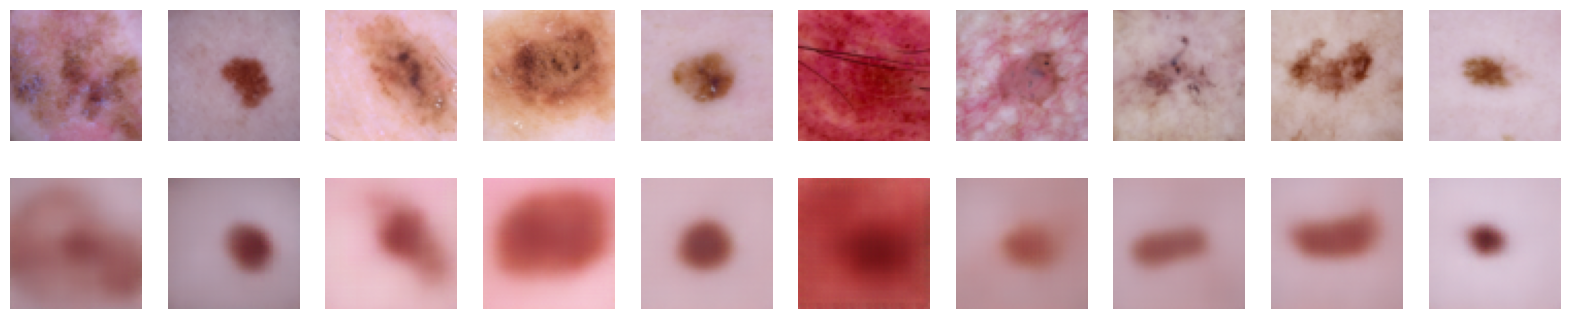

In [52]:
def plot_reconstructions(model, loader, n=10):
    model.eval()
    with torch.no_grad():
        images, _ = next(iter(loader))
        images = images.to(device)
        recon, _, _ = model(images)
        images = images.cpu()
        recon = recon.cpu()

    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
    for i in range(n):
        axes[0,i].imshow(images[i].permute(1,2,0))
        axes[0,i].axis("off")
        axes[1,i].imshow(recon[i].permute(1,2,0))
        axes[1,i].axis("off")
    axes[0,0].set_ylabel("Original")
    axes[1,0].set_ylabel("Reconstruction")
    plt.show()
plot_reconstructions(model, train_loader)

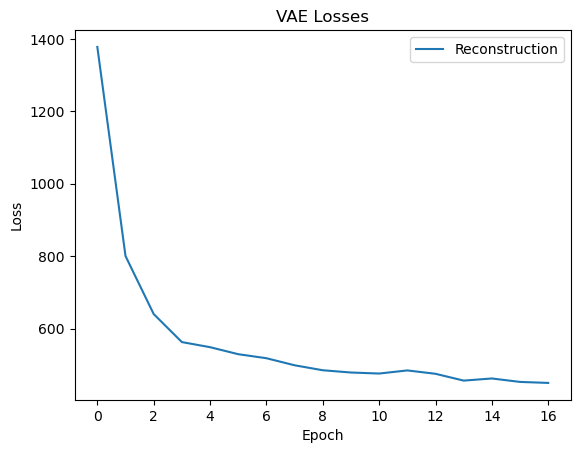

In [53]:
plt.figure()
plt.plot(train_recon_losses, label='Reconstruction')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("VAE Losses")
plt.show()

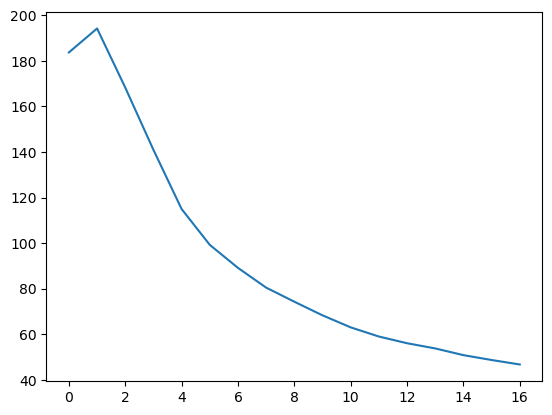

In [54]:
plt.plot(train_kld_losses, label='KL Divergence')

In [46]:
def sample_new_lesions(model, n=16):
    model.eval()
    with torch.no_grad():
        # Sample from standard normal latent space
        z = torch.randn(n, model.latent_dim).to(next(model.parameters()).device)
        samples = model.decode(z).cpu()  # shape: [n, 3, 64, 64]

    # Plot
    import torchvision
    grid = torchvision.utils.make_grid(samples, nrow=4)
    plt.figure(figsize=(6,6))
    plt.imshow(grid.permute(1,2,0))
    plt.axis("off")
    plt.title("Synthetic Lesions")
    plt.show()

In [47]:
def interpolate_lesions(model, loader, idx1=0, idx2=1, steps=8):
    model.eval()
    with torch.no_grad():
        images, _ = next(iter(loader))
        img1, img2 = images[idx1].unsqueeze(0), images[idx2].unsqueeze(0)
        
        # Encode to latent space
        mu1, logvar1 = model.encode(img1)
        z1 = model.reparameterize(mu1, logvar1)
        mu2, logvar2 = model.encode(img2)
        z2 = model.reparameterize(mu2, logvar2)
        
        # Linear interpolation
        interpolated = []
        for alpha in torch.linspace(0,1,steps):
            z = (1-alpha)*z1 + alpha*z2
            recon = model.decode(z)
            interpolated.append(recon.cpu())
        
        interpolated = torch.cat(interpolated, dim=0)
    
    # Plot
    import torchvision
    grid = torchvision.utils.make_grid(interpolated, nrow=steps)
    plt.figure(figsize=(steps,2))
    plt.imshow(grid.permute(1,2,0))
    plt.axis("off")
    plt.title("Latent Interpolation")
    plt.show()

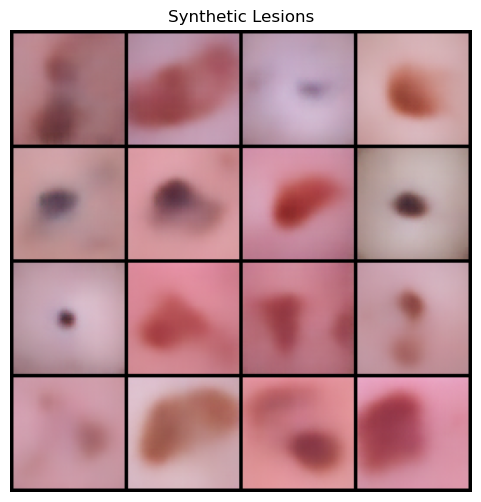

/tmp/ipykernel_16416/1387475648.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self.labels[idx])


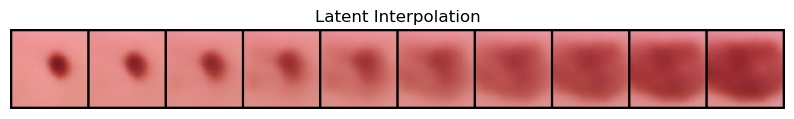

In [48]:
# Sample 4 random lesions
sample_new_lesions(model, n=16)

# Interpolate between first two images in validation set
interpolate_lesions(model, val_loader, idx1=0, idx2=1, steps=10)